<a href="https://colab.research.google.com/github/tgp989/operational-risk-prospectivity/blob/main/Reto_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación Prospectiva del Riesgo Operacional en Canales Electrónicos


En este espacio de trabajo se plantea como caso de estudio la evaluación prospectiva del riesgo operacional en los canales electrónicos de una entidad financiera líder, con el objetivo de transformar datos históricos de eventos de riesgo tecnológico en una herramienta analítica que facilite la toma de decisiones gerenciales, la optimización de los controles existentes y la reducción de pérdidas operacionales.

La entidad ha recibido una base de datos que contiene información sobre eventos de riesgo asociados a distintos canales electrónicos, como aplicaciones móviles, sucursales virtuales y cajeros automáticos. A partir de esta información, se busca identificar la exposición económica al riesgo, evaluar la eficacia de los controles implementados y desarrollar mecanismos prospectivos de mitigación basados en técnicas de analítica de datos y aprendizaje no supervisado.

El proceso de análisis se desarrolla bajo la metodología de riesgo operacional, iniciando con la construcción de una arquitectura integrada de matrices. En primer lugar, se elabora la matriz de frecuencia, que permite contabilizar el número de ocurrencias de los eventos. Posteriormente, se construye la matriz de severidad, en la cual los eventos son clasificados según el nivel de impacto o magnitud de las pérdidas generadas.

A partir de estas matrices, se desarrolla la matriz de pérdidas agregadas mediante la metodología LDA (Loss Distribution Approach), integrando frecuencia y severidad con el fin de estimar el impacto económico total derivado de las fallas tecnológicas. De manera complementaria, se construye la matriz de impacto y gestión, permitiendo analizar los riesgos según su nivel de criticidad y el tratamiento requerido para su mitigación.

En la fase de estimación cuantitativa, se calcula la Pérdida Esperada (PE) como medida base del riesgo operacional. Asimismo, se estima el Operational Value at Risk (OpVaR) con un nivel de confianza del 99,9%, permitiendo evaluar escenarios de pérdidas extremas. El análisis contempla tanto pérdidas no gestionadas (riesgo inherente) como pérdidas gestionadas (riesgo residual), evidenciando el efecto de los mecanismos de control sobre la distribución de pérdidas.

Adicionalmente, se implementa un modelo de agrupamiento K-Means con el propósito de segmentar los eventos de riesgo en clusters homogéneos según sus características operacionales y financieras. Esta metodología permite identificar perfiles diferenciados de riesgo, detectar eventos críticos y fortalecer el enfoque prospectivo de la gestión operacional mediante la priorización de estrategias de mitigación.

Como complemento al análisis financiero, se incorpora el cálculo del Valor Capturado Financiero y de los potenciales de captura de gases de efecto invernadero (GEI), utilizados como indicadores de eficiencia en la gestión prospectiva de riesgos. Estos indicadores permiten evaluar el beneficio económico y operacional derivado de la reducción de pérdidas tecnológicas dentro de la entidad financiera.

Finalmente, se diseña una herramienta de auditoría basada en filtros dinámicos, que permite seleccionar cualquier celda de la matriz de pérdidas y visualizar automáticamente el detalle de los eventos asociados junto con su descripción. Esta funcionalidad facilita la trazabilidad de la información, fortalece los procesos de supervisión y mejora la capacidad de análisis del riesgo operacional.

Los resultados obtenidos permiten a la entidad comprender mejor su exposición al riesgo tecnológico, evaluar la efectividad de sus controles, identificar oportunidades de mejora y tomar decisiones estratégicas orientadas a fortalecer la resiliencia operacional y la sostenibilidad de los canales electrónicos.

0. Se procede con la carga de las librerias de trabajo

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


0. Creamos la funcion de clusterizacion para poderla reutilzar varias veces

In [ ]:
def clusterizacion(Xi):

  # Proceso de clusterizacion
  XC=np.random.choice(Xi,size=5)
  XC=np.sort(XC) # Semillas de la Clusterizacion (Improbable, Posible, Ocasional, Probable, Frecuente)
  nc=np.zeros((len(Xi),1)) # Aqui clasifico los datos en cada una de las semillas

  for k in range(len(Xi)):
    d=np.abs(XC-Xi[k]) # Distacia de un dato a cada semilla
    nc[k]=np.argmin(d)
    nc2=np.int32(nc[k]) # Numero de pertenencia al cluster en enteros
    XC[nc2,]=(XC[nc2,]+Xi[k])/2 # Actualizamos la semilla a la que pertenece cada dato (K-Medoids)

  return XC,nc # Me retorna clusters y cluster al que pertenece un dato

1. Se cargan los archivos de trabajo

In [ ]:
from re import X
nxl='/content/drive/MyDrive/integración de datos y prospectiva/Reto 5/5. Riesgo Operacional FallasTecnológicas.xlsx'
XDB=pd.read_excel(nxl,sheet_name=0)
XDB.head()
np.random.seed(42)

# Obtenemos la variable de Frecuencia
Xf=np.array(XDB.iloc[1:,3])
XCf,ncf=clusterizacion(Xf)

# Obtenemos los cluster para la severidad
Xs=np.array(XDB.iloc[1:,4])
XCs,ncs=clusterizacion(Xs)

# Se procede a determinar la distribucion de las perdidas
LDA=Xf*Xs
XClda,nclda=clusterizacion(LDA)

# Creamos un dataframe de descarga
df=pd.DataFrame(np.column_stack((XDB.iloc[1:,1],XDB.iloc[1:,2], Xf,ncf,Xs,ncs,LDA,nclda,XDB.iloc[1:,5])))
df.columns=['Transacciones Diarias','Valor Transado (millones)', 'Freq','Nivel_f','Sev','Nivel_S','LDA','Nivel_LDA','Riesgos']

2. Procedemos con la construccion de la matriz de eventos de riesgo

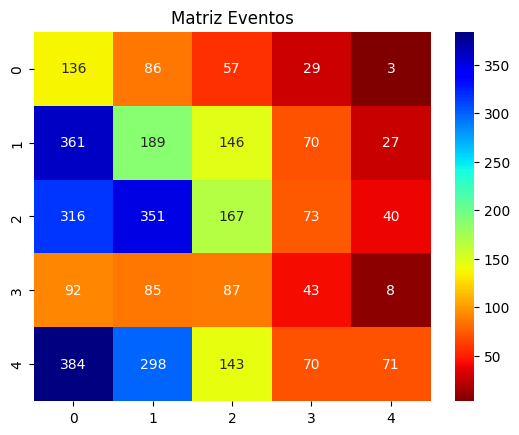

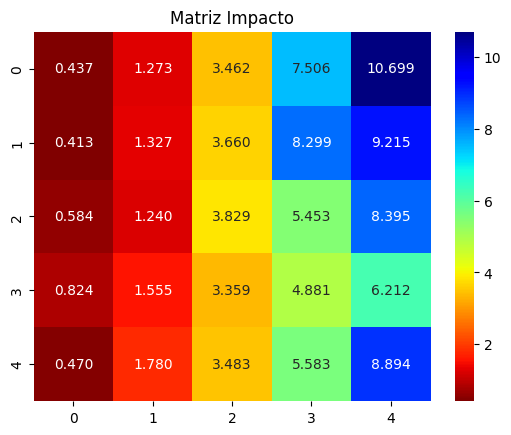

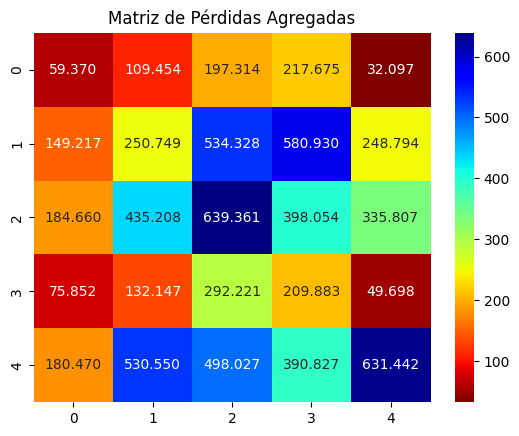

In [ ]:
MEf=np.zeros((5,5)) # Matriz frecuencia
MEs=np.zeros((5,5)) # Matriz severidad

for k in range(len(Xf)):
  nf=np.int32(df.iloc[k,3])   # Fila de frecuencia (Nivel_f is now at index 3)
  nc=np.int32(df.iloc[k,5])   # Columna de impacto (Nivel_S is now at index 5)
  MEf[nf,nc]=MEf[nf,nc]+Xf[k,]
  MEs[nf,nc]=(MEs[nf,nc]+Xs[k,])/2 # Costo promedio

plt.figure()
sns.heatmap(MEf,annot=True,fmt='.0f',cmap='jet_r')
plt.title('Matriz Eventos')
plt.show()

plt.figure()
sns.heatmap(MEs,annot=True,fmt='.3f',cmap='jet_r')
plt.title('Matriz Impacto')
plt.show()

MLDA = MEf * MEs # Matriz de Pérdidas Agregadas

plt.figure()
sns.heatmap(MLDA, annot=True, fmt='.3f', cmap='jet_r')
plt.title('Matriz de Pérdidas Agregadas')
plt.show()

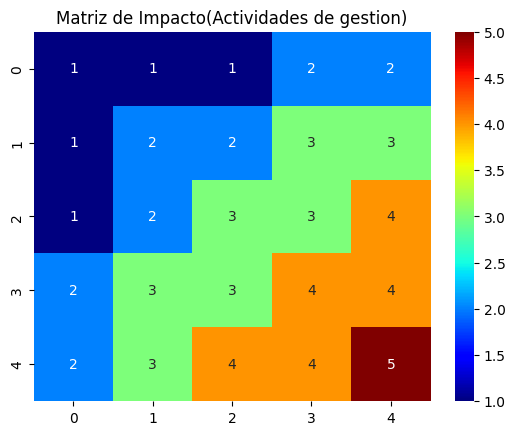

In [ ]:
# Procedemos con la creacion de la matriz de impacto
MI=np.array(([1,1,1,2,2],
            [1,2,2,3,3],
            [1,2,3,3,4],
            [2,3,3,4,4],
            [2,3,4,4,5]))

plt.figure()
sns.heatmap(MI,annot=True,fmt='.0f',cmap='jet')
plt.title('Matriz de Impacto(Actividades de gestion)')
plt.show()

Ingresar el Nivel de Gestion (1,2,3,4):2


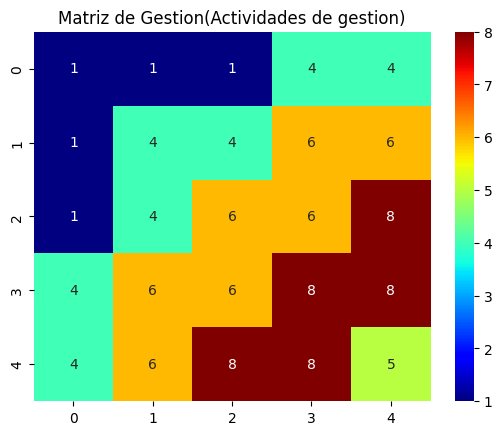

In [ ]:
# Matriz de Gestion - Involucra recursos de la Organizacion
NG=np.int32(input("Ingresar el Nivel de Gestion (1,2,3,4):"))
MG=np.copy(MI)

for i in range(5): # Si es mayor que 1 y menor que 5 incremente la gestion
  for j in range(5):
    if MG[i,j]>1 and MG[i,j]<5:
      MG[i,j]=MG[i,j]*NG

plt.figure()
sns.heatmap(MG,annot=True,fmt='.0f',cmap='jet')
plt.title('Matriz de Gestion(Actividades de gestion)')
plt.show()

3. Estimación Cuantitativa

In [ ]:
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)

np.random.seed(42)
df["gestionado"] = np.random.choice(["Gestionado", "No Gestionado"], size=len(df))

In [ ]:
#1. Perdida Esperada por Promedio Simple
ps=np.mean(MEs)
print("El promedio simple de severidad por atender una falla es:",ps)

#2. Perdida Esperada por Promedio Ponderado
pp=np.sum(MEf*MEs)/np.sum(MEf)
print("El promedio ponderado de severidad por atender una falla es:",pp)

#3. Se procede a determinar la perdida ponderada teniendo igualmente la matriz de Impacto - Nivel de Riesgo
pnr=np.sum(MEf*MEs*MI)/np.sum(MEf*MI)
print("El promedio ponderado de severidad por atender una falla es:",pnr)

#4. Se procede a determinar la perdida ponderada teniendo igualmente la matriz de Gestion
png=np.sum(MEf*MEs*MI)/np.sum(MEf*MG)
print(f"El promedio ponderado de severidad por atender una falla con un nivel de gestion {NG} es:",png)

#5. Operational Value at Risk (OpVaR)
OpVaR = np.percentile(df["LDA"], 99.9)
print("El valor operativo en riesgo a un nivel de confianza del 99.9% es:", OpVaR)

no_gestionado = df[df["gestionado"] == "No Gestionado"]["LDA"]
gestionado = df[df["gestionado"] == "Gestionado"]["LDA"]

print("El valor operativo con riesgo inherente es:", np.percentile(no_gestionado, 99.9))
print("El valor operativo con riesgo residual es:", np.percentile(gestionado, 99.9))

El promedio simple de severidad por atender una falla es: 4.113245727909984
El promedio ponderado de severidad por atender una falla es: 2.2101248413091006
El promedio ponderado de severidad por atender una falla es: 2.959804567539658
El promedio ponderado de severidad por atender una falla con un nivel de gestion 2 es: 1.6251123649031458
El valor operativo en riesgo a un nivel de confianza del 99.9% es: 102.9021000000008
El valor operativo con riesgo inherente es: 100.47547820000042
El valor operativo con riesgo residual es: 94.15458000000048


**Análisis de Resultados**
El promedio simple de severidad por atender una falla es de aproximadamente 4.11, lo que indica que, en términos generales, cada evento de riesgo tiene un impacto relevante sobre la operación. Sin embargo, al analizar el promedio ponderado, se observa que el costo real esperado por evento se reduce a valores entre 2.21 y 2.95, lo que evidencia que los eventos más frecuentes tienden a ser de menor severidad, reduciendo el impacto promedio efectivo.

De acuerdo con la integración de la matriz de impacto, se identifica que la pérdida esperada puede variar dependiendo de la relevancia de los eventos dentro de la matriz de frecuencia, concentrándose el riesgo en aquellos eventos menos frecuentes pero más severos. Al incorporar niveles de gestión, específicamente en un nivel de gestión 2, la severidad ponderada se reduce a aproximadamente 1.62, lo que demuestra que la implementación de controles tiene un efecto significativo en la mitigación del riesgo.

Por otro lado, el Valor en Riesgo Operacional (OpVaR) al 99.9% se estima en 102.90, reflejando la exposición a eventos extremos. Al comparar el riesgo inherente (100.48) con el riesgo residual (94.15), se evidencia una reducción gracias a la gestión del riesgo, aunque esta disminución no es lo suficientemente amplia como para eliminar completamente la exposición a pérdidas severas.

**Matriz de Impacto:**
Esta matriz permite identificar el nivel de impacto que tienen los diferentes eventos de riesgo sobre las pérdidas de la organización, destacando aquellos eventos que, aunque poco frecuentes, pueden generar consecuencias económicas significativas.

**Matriz de Gestión:**
Esta matriz complementa la matriz de impacto al establecer el nivel de atención que requiere cada tipo de evento de riesgo. A mayor nivel de gestión, mayor es la intervención y los recursos asignados para mitigar el riesgo. Es importante considerar que la gestión implica costos operativos; sin embargo, su correcta implementación contribuye a reducir la probabilidad de pérdidas catastróficas y a disminuir el riesgo residual de la organización.


4. Herramienta de Auditoría (Filtro Dinámico)

In [ ]:
fila=np.int32(input("ingresar el Nivel para la Frecuencia "))
col=np.int32(input("Ingresar el Nivel para la Severidad "))
df[(df.iloc[:,3]==fila)&(df.iloc[:,5]==col)]

ingresar el Nivel para la Frecuencia 2
Ingresar el Nivel para la Severidad 2


,Transacciones Diarias,Valor Transado (millones),Freq,Nivel_f,Sev,Nivel_S,LDA,Nivel_LDA,Riesgos,gestionado
4,130,23.4112,7,2.0,1.2105,2.0,8.4735,4.0,"Errores en la interfaz de usuario, fallas en f...",Gestionado
41,120,8.1649,7,2.0,1.3855,2.0,9.6985,2.0,"Errores en la interfaz de usuario, fallas en f...",Gestionado
44,110,28.0397,6,2.0,1.2693,2.0,7.6158,2.0,"Errores en la interfaz de usuario, fallas en f...",No Gestionado
56,80,18.4558,7,2.0,1.827,2.0,12.789,2.0,"Errores en la interfaz de usuario, fallas en f...",No Gestionado
102,120,21.5957,7,2.0,1.749,2.0,12.243,2.0,"Errores en la interfaz de usuario, fallas en f...",No Gestionado
110,105,20.1974,6,2.0,1.6892,2.0,10.1352,2.0,"Errores en la interfaz de usuario, fallas en f...",No Gestionado
143,80,24.8284,6,2.0,2.1317,2.0,12.7902,2.0,"Errores en la interfaz de usuario, fallas en f...",No Gestionado
157,95,26.9554,6,2.0,2.6077,2.0,15.6462,2.0,"Degradación del rendimiento por varias horas, ...",No Gestionado
191,115,14.5681,5,2.0,2.2048,2.0,11.024,2.0,"Errores en la interfaz de usuario, fallas en f...",Gestionado
196,130,6.6179,6,2.0,1.8272,2.0,10.9632,2.0,"Errores en la interfaz de usuario, fallas en f...",No Gestionado


**Conclusión – Herramienta de Auditoría de la Matriz de Pérdidas**

La implementación de la herramienta de auditoría basada en el filtro dinámico de la matriz de pérdidas permite transformar el análisis de riesgo operacional en un proceso más transparente, trazable y orientado a la toma de decisiones. A través de esta funcionalidad, es posible seleccionar cualquier combinación de evento y nivel de severidad, y acceder de manera inmediata al detalle de los registros que componen dicha celda, incluyendo variables operativas y la pérdida estimada.

Este enfoque facilita la identificación de patrones específicos dentro de los eventos de riesgo, permitiendo distinguir cuáles son los principales generadores de pérdidas y cómo se distribuyen en el tiempo. Asimismo, la herramienta fortalece la capacidad de validación y control, ya que permite verificar la consistencia de los resultados agregados frente a los datos originales, reduciendo la opacidad en el análisis.

Adicionalmente, la posibilidad de profundizar en cada segmento de la matriz contribuye a mejorar la gestión del riesgo, al enfocar los esfuerzos en eventos críticos y en aquellos casos donde los controles no están siendo suficientemente efectivos. En este sentido, la herramienta no solo cumple una función descriptiva, sino que se convierte en un apoyo clave para la toma de decisiones estratégicas y la optimización de los mecanismos de mitigación.

En conclusión, la herramienta de auditoría añade valor significativo al modelo de riesgo operacional, al integrar análisis cuantitativo con capacidad de exploración detallada, permitiendo una gestión más precisa, informada y proactiva frente a los riesgos identificados.


# Parcial 2

La siguiente etapa corresponde a la caracterización de la Distribución Agregada de Pérdidas (LDA: Loss Distribution Approach) y de sus principales parámetros de riesgo operacional asociados a fallas tecnológicas en la FINTECH.

La metodología LDA permite analizar el comportamiento de las pérdidas derivadas de eventos operacionales mediante la integración de la frecuencia y severidad de las fallas, facilitando la identificación de diferentes niveles de exposición al riesgo.

Los parámetros de riesgo considerados son los siguientes:

* C1: Pérdidas Esperadas

Corresponden a eventos de bajo impacto y alta recurrencia, asociados a fallas operativas menores dentro de los canales electrónicos, como errores temporales de autenticación, lentitud en las transacciones o interrupciones de corta duración.
* C2: Pérdidas No Esperadas o Gestionables

Representan eventos con impacto moderado que requieren mecanismos de gestión y mitigación para evitar afectaciones mayores, como caídas parciales de servicios, errores en procesos de validación o fallas recurrentes en plataformas transaccionales.
* C3: Pérdidas Catastróficas

Corresponden a eventos de alto impacto y baja frecuencia que pueden comprometer significativamente la operación de la entidad, como interrupciones masivas de servicios, vulneraciones de ciberseguridad, ataques informáticos o fallas críticas en la infraestructura tecnológica.

In [ ]:
# Se procede con la grafica de la distribucion de perdidas (LDA)
LDA = np.array(df['LDA'])
LC1=np.mean(LDA); print("El limite de las perdidas esperadas (C1) es:", LC1)
OpVar=np.percentile(LDA,99.9); print("El limite inferior de las perdidas (C3) es:", OpVar)

# Contabilizamos el numero de fallas por categoria de riesgo
nc_c1 = np.sum(LDA < LC1)
print("El numero de fallas con perdidas menores a C1 son:",nc_c1)
nc_c3 = np.sum(LDA > OpVar)
print("El numero de fallas con perdidas mayores al OpVar son:",nc_c3)
nc_c2 = len(df) - nc_c1 - nc_c3
print("El numero de fallas con perdidas Gestionables (C2) son:",nc_c2)

# Los valores porcentuales de riesgo son:
print("El porcentaje de riesgo C1 es:",nc_c1/len(df))
print("El porcentaje de riesgo C2 es:",nc_c2/len(df))
print("El porcentaje de riesgo C3 es:",nc_c3/len(df))

# Gestion de Riesgos - Captura GEI (Gases Efecto Invernadero)
nimp = np.array(df['Nivel_LDA'] + 1)
ngest=np.int32(input("Me puedes ingresar el nivel de gestion (1,2,3,4):"))
ng2=nimp*ngest
df['Nivel_LDA']=nimp
df['Nivel de Gestion']=ng2

# Se procede a determinar la distribucion de perdidas gestionada
LDA_G=LDA*(nimp/ng2)
df['LDA_Gestionada']=LDA_G

El limite de las perdidas esperadas (C1) es: 9.45111269614836
El limite inferior de las perdidas (C3) es: 102.9021000000008
El numero de fallas con perdidas menores a C1 son: 502
El numero de fallas con perdidas mayores al OpVar son: 1
El numero de fallas con perdidas Gestionables (C2) son: 198
El porcentaje de riesgo C1 es: 0.7161198288159771
El porcentaje de riesgo C2 es: 0.28245363766048504
El porcentaje de riesgo C3 es: 0.0014265335235378032
Me puedes ingresar el nivel de gestion (1,2,3,4):2


**Integracion K-Means**

Con el objetivo de fortalecer el enfoque prospectivo de la gestión de riesgos operacionales, se implementó el algoritmo de agrupamiento K-Means sobre las variables asociadas a las pérdidas tecnológicas de la FINTECH. Este modelo de aprendizaje no supervisado permite identificar patrones de comportamiento similares entre los eventos de riesgo, segmentando las fallas en diferentes grupos o clusters según sus características operacionales y financieras.

Para la construcción del modelo se utilizaron variables relacionadas con la frecuencia de fallas, severidad de las pérdidas, valor transado y pérdidas gestionadas, permitiendo clasificar los eventos en grupos homogéneos de riesgo. Previamente, las variables fueron normalizadas mediante técnicas de escalamiento con el fin de evitar sesgos derivados de diferencias en magnitud entre las variables analizadas.

Posteriormente, se aplicó el método del codo para determinar el número óptimo de clusters, evaluando la reducción de la inercia del modelo a medida que aumenta el número de agrupaciones. Una vez definido el número adecuado de clusters, el modelo permitió identificar diferentes perfiles de riesgo operacional dentro de la entidad financiera.

La integración de K-Means facilita la identificación de grupos de eventos críticos, eventos recurrentes y eventos de bajo impacto, permitiendo priorizar estrategias de mitigación y orientar de manera más eficiente los recursos destinados a la gestión prospectiva de riesgos tecnológicos.

Seleccion de variables

In [ ]:
X = df[[
    'Transacciones Diarias',
    'Valor Transado (millones)',
    'Freq',
    'LDA',
    'LDA_Gestionada'
]]

Escalado de variables

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Metodo del codo

In [ ]:
from sklearn.cluster import KMeans

inercias = []

for k in range(1,10):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(X_scaled)

    inercias.append(modelo.inertia_)

Grafico del codo

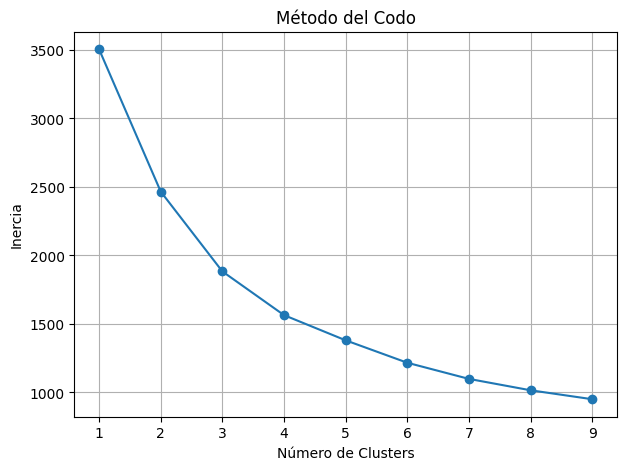

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(range(1,10), inercias, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.grid()
plt.show()

Modelo final

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

Resultados

In [ ]:
df[['LDA','LDA_Gestionada','Cluster']].head()

,LDA,LDA_Gestionada,Cluster
0,0.5374,0.2687,1
1,4.7912,2.3956,2
2,2.1345,1.06725,1
3,6.4884,3.2442,0
4,8.4735,4.23675,0


Interpretacion

In [ ]:
Resumen_Clusters = df.groupby('Cluster')[[
    'LDA',
    'LDA_Gestionada',
    'Freq'
]].mean()

print(Resumen_Clusters)

               LDA LDA_Gestionada      Freq
Cluster                                    
0        12.629817       6.314909  7.676056
1         3.840013       1.920006   2.87013
2         4.417863       2.208931  3.309091
3        56.110976      28.055488   8.27027


Visualizacion

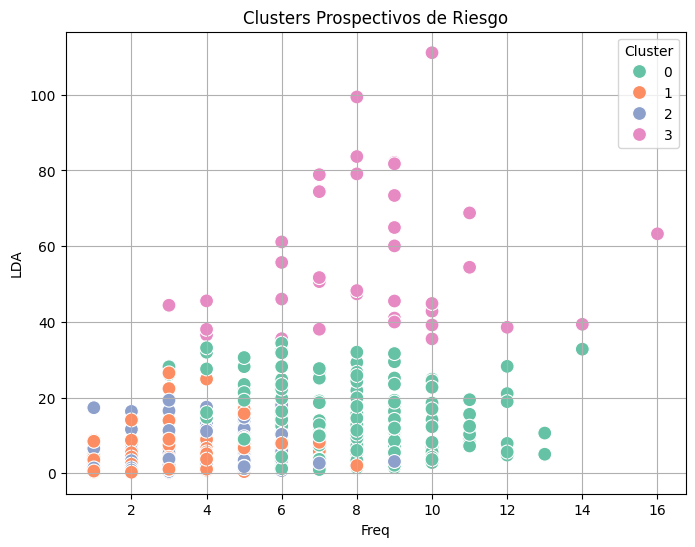

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Freq',
    y='LDA',
    hue='Cluster',
    palette='Set2',
    s=100
)

plt.title('Clusters Prospectivos de Riesgo')
plt.grid()
plt.show()

El modelo K-Means permitió segmentar los eventos operacionales en grupos homogéneos según sus características de pérdida, frecuencia e impacto operacional. Esto facilita la identificación de perfiles de riesgo diferenciados y fortalece el enfoque prospectivo de gestión, permitiendo priorizar controles sobre los clusters con mayor exposición financiera.

**Valor capturado financiero y captura GEI**

El numero de fallas en C1 luego de una gestion 1:2 son: 611
El numero de fallas en C3 luego de una gestion 1:2 son: 0
El numero de fallas en C2 luego de una gestion 1:2 son: 90
El numero de fallas que migran de C2-C1 son: 109
La perdida promedio es: 2.959804567539658
El costo de la gestion de una falla es: 0.0374
El valor capturado financiero es: 314.4654978618227
El numero de toneladas de gases de efecto invernadero por año: 3.144654978618227


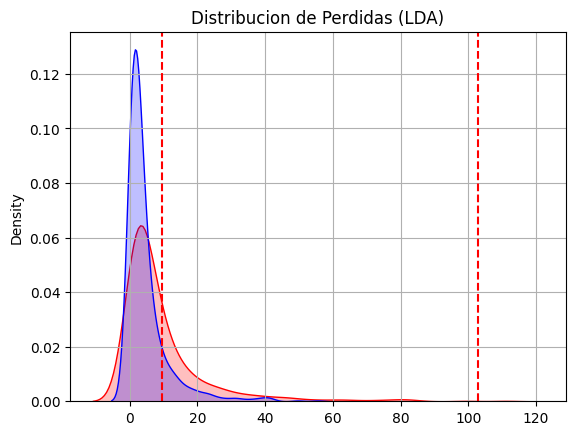

In [ ]:
# Procedemos a contar los contenedores
nc_c1_g = np.sum(LDA_G < LC1)
nc_c3_g = np.sum(LDA_G > OpVar)
nc_c2_g = len(df) - nc_c1_g - nc_c3_g
print(f"El numero de fallas en C1 luego de una gestion 1:{ngest} son:",nc_c1_g)
print(f"El numero de fallas en C3 luego de una gestion 1:{ngest} son:",nc_c3_g)
print(f"El numero de fallas en C2 luego de una gestion 1:{ngest} son:",nc_c2_g)

# Valor Capturado Financiero
ncg=nc_c1_g-nc_c1
print("El numero de fallas que migran de C2-C1 son:",ncg)
PProm=2.959804567539658 # Perdida de una falla

costos_gestion = {
    1: 0.0122,
    2: 0.0374,
    3: 0.1731,
    4: 0.4080,
    5: 0.6283
}

CGest=costos_gestion[ngest]

VCapt=ncg*(PProm-(CGest*ngest)) # Valor Capturado - Evito que las fallas sean C3
print("La perdida promedio es:",PProm)
print("El costo de la gestion de una falla es:",CGest)
print("El valor capturado financiero es:",VCapt)
TGEI=100 # Esto pagan por tonelada captura de GEI (Gases Efecto Invernadero)
TCaptGEI=VCapt/TGEI
print("El numero de toneladas de gases de efecto invernadero por año:",TCaptGEI)

plt.figure()
sns.kdeplot(LDA,fill=True,color='Red')
sns.kdeplot(LDA_G,fill=True,color='Blue')
plt.axvline(x=LC1,color='Red',linestyle='--')
plt.axvline(x=OpVar,color='Red',linestyle='--')
plt.title('Distribucion de Perdidas (LDA)')
plt.grid()
plt.show()

**Interpretación del Gráfico de Distribución de Pérdidas (LDA)**

La gráfica de distribución agregada de pérdidas (LDA) permite visualizar el comportamiento probabilístico de las pérdidas operacionales antes y después de la aplicación de estrategias de gestión de riesgos. En el gráfico, la distribución en color rojo representa el riesgo inherente, es decir, las pérdidas iniciales asociadas a las fallas tecnológicas antes de aplicar mecanismos de mitigación. Por su parte, la distribución en color azul representa el riesgo residual o gestionado, correspondiente a las pérdidas luego de implementar controles y estrategias de gestión prospectiva.

Se observa que la distribución gestionada presenta una mayor concentración hacia valores bajos de pérdida, evidenciando una reducción significativa de eventos extremos y una disminución en la dispersión de las pérdidas operacionales. Esto indica que la aplicación de medidas de gestión contribuye a desplazar una parte importante de los eventos desde categorías de riesgo moderado o crítico hacia categorías de menor impacto financiero.

Las líneas verticales punteadas representan los límites de clasificación de riesgo definidos mediante la metodología LDA. El primer límite corresponde al umbral de pérdidas esperadas (C1), mientras que el segundo representa el límite asociado a pérdidas catastróficas o Operational Value at Risk (OpVaR) al nivel de confianza definido. Estos umbrales permiten clasificar los eventos operacionales en diferentes categorías de exposición al riesgo y evaluar el efecto de las estrategias de mitigación implementadas.

En términos generales, la gráfica evidencia que la gestión prospectiva aplicada sobre las fallas tecnológicas reduce la exposición de la FINTECH a pérdidas severas, mejora la estabilidad operacional y aumenta la eficiencia de los controles implementados dentro de los canales electrónicos.

**Análisis de Resultados**

De acuerdo con los resultados obtenidos y para un nivel de gestión prospectiva de riesgos 1:2, se puede observar que se logró movilizar un total de 109 fallas desde la categoría de riesgo gestionable C2 hacia la categoría de menor riesgo C1. Antes de la gestión, la categoría C1 contaba con 502 fallas clasificadas como pérdidas menores al límite esperado; posteriormente, luego de la aplicación de estrategias de mitigación y control, esta categoría aumentó a 611 fallas, evidenciando una reducción significativa en la exposición al riesgo operacional.

Asimismo, se observa que el número de fallas ubicadas en la categoría de pérdidas extremas C3 se redujo completamente a cero después de la gestión aplicada, lo que demuestra la efectividad de las medidas implementadas sobre los eventos críticos asociados a fallas tecnológicas dentro de la FINTECH.

El análisis financiero muestra que la pérdida promedio asociada a una falla fue de aproximadamente 2.96, mientras que el costo de gestión por evento para un nivel de intervención 2 fue de 0.0374. Como resultado de la gestión prospectiva, el valor capturado financiero alcanzó un total aproximado de 314.46, representando el beneficio económico derivado de la mitigación de pérdidas operacionales.

Finalmente, el modelo estima un potencial de captura de gases de efecto invernadero (GEI) equivalente a 3.14 toneladas por año. Este indicador representa el impacto positivo asociado a la reducción del riesgo y a la mejora en la eficiencia operativa producto de la gestión prospectiva implementada. Dicho potencial de captura se interpreta como un indicador complementario de sostenibilidad financiera y operacional dentro del marco de gestión de riesgos tecnológicos.
